# Import Libraries

In [79]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

from datasets import load_dataset

from nltk.tokenize import word_tokenize

from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

from gensim.models import Word2Vec

from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments
from datasets import Dataset

# Download NLTK Resources

In [61]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mukta\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\mukta\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mukta\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\mukta\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\mukta\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\mukta\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_pe

True

# Load Datasets

In [62]:
datasets = load_dataset("stanfordnlp/imdb")

In [63]:
train_df = pd.DataFrame(datasets['train'])
test_df = pd.DataFrame(datasets['test'])

In [64]:
train_df.head()

,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [65]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    25000 non-null  str  
 1   label   25000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 32.0 MB


In [66]:
train_df['label'].value_counts()

label
0    12500
1    12500
Name: count, dtype: int64

<Axes: xlabel='label', ylabel='count'>

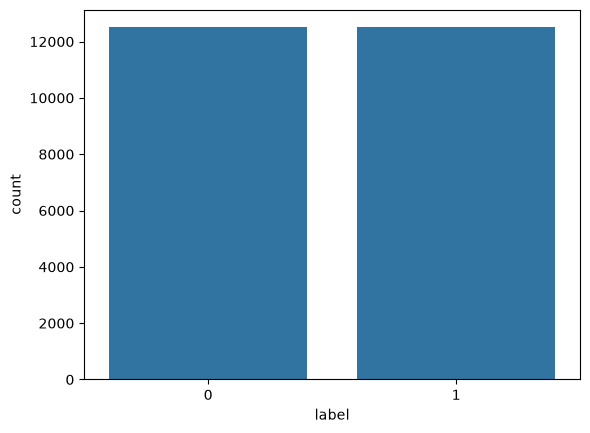

In [67]:
sns.countplot(data=train_df, x='label')

# Text Preprocessing

In [9]:
# Text Cleaning
def clean_text(text):

    text = text.lower()

    text = re.sub(r"<.*?>","",text) # Removes HTML tags (like <div> or <p>).

    text = re.sub(r"http\S+","",text) # Removes website URLs starting with "http".Matches all characters until a whitespace appe

    text = re.sub(r"\d+","",text) # Removes all digits and numbers.

    # Removes all punctuation marks (e.g., !, ?, ., ,).
    text = text.translate(
        str.maketrans(
            "",
            "",
            string.punctuation
        )
    )

    return text

In [10]:
train_df['clean'] = train_df['text'].apply(clean_text)

In [12]:
train_df['clean'].head()

0    i rented i am curiousyellow from my video stor...
1    i am curious yellow is a risible and pretentio...
2    if only to avoid making this type of film in t...
3    this film was probably inspired by godards mas...
4    oh brotherafter hearing about this ridiculous ...
Name: clean, dtype: str

In [13]:
# Tokenization
train_df['tokens'] = train_df['clean'].apply(word_tokenize)

In [14]:
train_df['tokens'].head()

0    [i, rented, i, am, curiousyellow, from, my, vi...
1    [i, am, curious, yellow, is, a, risible, and, ...
2    [if, only, to, avoid, making, this, type, of, ...
3    [this, film, was, probably, inspired, by, goda...
4    [oh, brotherafter, hearing, about, this, ridic...
Name: tokens, dtype: object

In [15]:
# Stopwords removal
stop_words = set(stopwords.words('English'))
def stopwords_removal(words):
    filetered_words = [word for word in words if word not in stop_words]
    return filetered_words
train_df['tokens'] = train_df['tokens'].apply(stopwords_removal)
train_df['tokens'].head()

0    [rented, curiousyellow, video, store, controve...
1    [curious, yellow, risible, pretentious, steami...
2    [avoid, making, type, film, future, film, inte...
3    [film, probably, inspired, godards, masculin, ...
4    [oh, brotherafter, hearing, ridiculous, film, ...
Name: tokens, dtype: object

In [16]:
# Lemmatization
# Verbs: "running", "ran", and "runs" all become "run".
lematizer = WordNetLemmatizer()
def get_wordnet_pos(word):
    """Map NLTK POS tag to WordNet POS tag."""
    tag = nltk.pos_tag([word])[0][1][0].upper()
    tag_dict = {"J": wordnet.ADJ,
                "R": wordnet.ADV,
                "V": wordnet.VERB,
                "N": wordnet.NOUN}
    return tag_dict.get(tag, wordnet.NOUN) # Default to noun

def lemmatize(words):
    # Pass the correct POS tag to the lemmatizer
    return [lematizer.lemmatize(word, get_wordnet_pos(word)) for word in words]

train_df['tokens'] = train_df['tokens'].apply(lemmatize)
train_df['tokens'].head()

0    [rent, curiousyellow, video, store, controvers...
1    [curious, yellow, risible, pretentious, steam,...
2    [avoid, make, type, film, future, film, intere...
3    [film, probably, inspire, godard, masculin, fé...
4    [oh, brotherafter, hearing, ridiculous, film, ...
Name: tokens, dtype: object

# TF-IDF

In [17]:
# Convert tokens back into text.
train_df['processed'] = train_df['tokens'].apply(lambda x:" ".join(x))

In [18]:
vectorizer = TfidfVectorizer(max_features=10000)

In [19]:
X_train = vectorizer.fit_transform(train_df['processed'])
X_test = vectorizer.fit_transform(train_df['processed'])

In [20]:
y_train = train_df['label']
y_test = test_df['label']

# Logistic Regrression

In [21]:
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train,y_train)
prediction_lr = model_lr.predict(X_test)
accuracy_score(y_test, prediction_lr)

0.92036

# Word2Vec

Word2Vec is a deep learning technique that converts words into dense vectors (lists of numbers) where the location of the words captures their semantic meaning.

In [38]:
# This builds vectors based on word context within the dataset
w2v_model = Word2Vec(
    sentences = train_df['tokens'],
    vector_size = 100,
    window = 5,
    min_count = 2
)

In [39]:
w2v_model.wv.most_similar(
    "movie"
)

[('film', 0.8047536611557007),
 ('moviei', 0.6862772107124329),
 ('flick', 0.6832562685012817),
 ('sequel', 0.6219281554222107),
 ('honestly', 0.6061692237854004),
 ('fffc', 0.6004061698913574),
 ('damn', 0.589604377746582),
 ('iti', 0.5886303186416626),
 ('filmi', 0.5874783396720886),
 ('anyway', 0.5786593556404114)]

In [40]:
len(w2v_model.wv)

45712

In [42]:
X_train = train_df["text"]
y_train = train_df["label"]

X_test = test_df["text"]
y_test = test_df["label"]

In [43]:
train_tokens = X_train.apply(word_tokenize)
test_tokens = X_test.apply(word_tokenize)

print(train_tokens.iloc[0][:20])

['I', 'rented', 'I', 'AM', 'CURIOUS-YELLOW', 'from', 'my', 'video', 'store', 'because', 'of', 'all', 'the', 'controversy', 'that', 'surrounded', 'it', 'when', 'it', 'was']


In [28]:
# Vector Averaging function
# Convert Each Review to a Fixed-Length Vector
def average_words_vector (tokens, model, vector_size):
    vectors = []
    for word in tokens:
        if word in model.wv:
            vectors.append(model.wv[word])
    if len(vectors)==0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

In [29]:
# Create Feature Matrices
X_train_vectors = np.array([average_words_vector(doc, w2v_model, 100) for doc in train_tokens])
X_test_vectors  = np.array([average_words_vector(doc, w2v_model, 100) for doc in test_tokens])

In [30]:
print(X_train_vectors.shape)
print(X_test_vectors.shape)

(25000, 100)
(25000, 100)


# Logistic Regression

In [31]:
model_lr_w2v = LogisticRegression(max_iter=100)
model_lr_w2v.fit(X_train_vectors, y_train)
prediction_lr_w2v = model_lr_w2v.predict(X_test_vectors)
accuracy_score(y_test, prediction_lr_w2v)

0.799